In [1]:
import pandas as pd

df = pd.read_csv('properties_master.csv')
print(len(df))

1066


In [2]:
_PROP = 'cetane_number'

smiles = df['canonical_smiles']
prop = df['properties.{}.value'.format(_PROP)]

smiles = [smiles[idx] for idx in range(len(smiles)) if prop[idx] != '-']
prop = [float(prop[idx]) for idx in range(len(prop)) if prop[idx] != '-']

print(len(smiles), len(prop))

408 408


In [3]:
from alvadescpy import smiles_to_descriptors

descriptors = [smiles_to_descriptors(smi, labels=False) for smi in smiles]

In [4]:
import numpy as np

for idx, d in enumerate(descriptors):
    for d_idx, val in enumerate(d):
        if val == 'na':
            descriptors[idx][d_idx] = 0.0

formatted_desc = np.array(descriptors).astype('float')
print(formatted_desc.shape)

formatted_desc_reduced = formatted_desc[:, :1500]
print(formatted_desc_reduced.shape)

(408, 5305)
(408, 1500)


<AxesSubplot:>

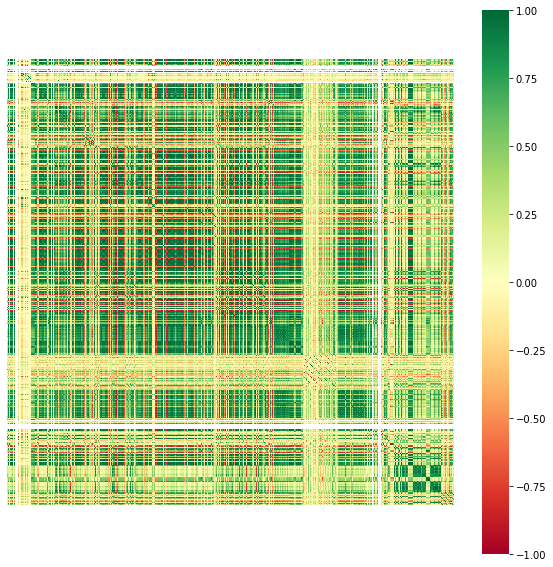

In [5]:
import seaborn as sns
from matplotlib import pyplot as plt

df_desc = pd.DataFrame(formatted_desc_reduced, columns=['{}'.format(i) for i in range(1, len(formatted_desc_reduced[0]) + 1)])
desc_corr = df_desc.corr()

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    desc_corr,
    vmin=-1,
    vmax=1,
    center=0,
    cmap='RdYlGn',
    square=True,
    xticklabels=False,
    yticklabels=False
)